In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import entropy
from scipy.special import expit
import os
from sklearn.linear_model import LogisticRegression
import pandas as pd

K = 1 + 3. 322 logN

In [2]:
dirs = sorted(os.listdir('./'))
dirs = list(filter(lambda x : x if x.startswith('srl_multi') else None, dirs))
curr_dir = random.sample(dirs, 1).pop()
dirs, curr_dir

(['srl_multi_pre_thres_un10_score_discrim',
  'srl_multi_pre_thres_un10_score_discrim_loss_scaling',
  'srl_multi_pre_thres_un10_score_discrim_ls_y_hat',
  'srl_multi_pre_thres_un10_score_quantile0.1',
  'srl_multi_pre_thres_un10_score_quantile0.25',
  'srl_multi_pre_thres_un10_score_quantile0.5',
  'srl_multi_pre_thres_un10_score_quantile0.75',
  'srl_multi_pre_thres_un10_score_quantile0.9',
  'srl_multi_thres_un10_score_discrim',
  'srl_multi_thres_un10_score_discrim_accumul1',
  'srl_multi_thres_un10_score_discrim_loss_scaling',
  'srl_multi_thres_un10_score_discrim_ls_y_hat',
  'srl_multi_thres_un10_score_quantile0.1',
  'srl_multi_thres_un10_score_quantile0.25',
  'srl_multi_thres_un10_score_quantile0.5',
  'srl_multi_thres_un10_score_quantile0.75',
  'srl_multi_thres_un10_score_quantile0.9'],
 'srl_multi_thres_un10_score_quantile0.5')

In [3]:
import os
import pandas as pd

dirs = sorted(os.listdir('./'))
dirs = list(filter(lambda x : x if x.startswith('srl_multi') else None, dirs))
dirs = list(filter(lambda x: x if 'thres' in x else None, dirs))

df = pd.DataFrame()
for cur_dir in dirs:
    if not os.path.exists(cur_dir+'/summary.csv') :
        continue
    tmp = pd.read_csv(cur_dir+'/summary.csv', sep='\t')
    tmp = tmp.reset_index()
    tmp[['index']] = '_'.join(cur_dir.split("_")[1:])
    df = pd.concat((df, tmp))
# df = df.drop(columns='loss')
# df.to_csv('./overall-summary.csv')

# df = pd.DataFrame()
# for cur_dir in dirs:
#     if 
#     tmp = pd.read_csv(cur_dir+'/summary.csv', sep='\t')
#     tmp = tmp.reset_index()
#     tmp[['index']] = '_'.join(cur_dir.split("_")[1:])
#     df = pd.concat((df, tmp))
# df = df.drop(columns='loss')
# df.to_csv('./overall-summary.csv')

<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
tmp
0


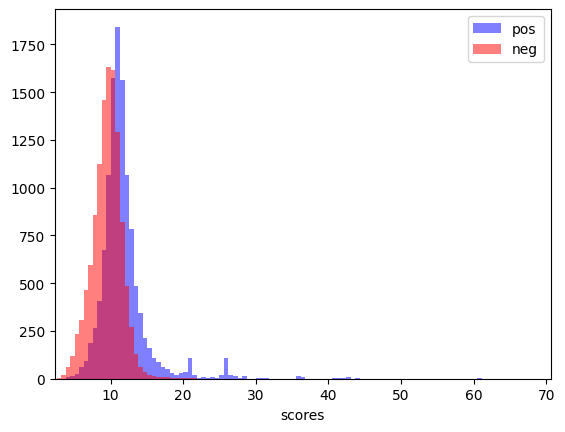

In [54]:
for cur_dir in ['tmp']:
    print("<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
    print(cur_dir)
    
    for ep in range(0,1):
        print('===========================================================')
        print(ep)

#         thress = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_thresshold.pt')
#         thres = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_threshold.pt')
        
        pos = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_score_pos.pt').cpu()
        neg = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_score_neg.pt').cpu()
        
        pos_word = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_prob_words.pt')
        pos_word = torch.tensor(list(map(lambda x: len(x), pos_word))).unsqueeze(-1).float()
        neg_word = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_neg_words.pt')
        neg_word = torch.tensor(list(map(lambda x: len(x), neg_word))).unsqueeze(-1).float()
        
        pos = torch.div(pos, pos_word).numpy()
        neg = torch.div(neg, neg_word).numpy()
#         print("thress:", thress)
#         print("thres:", thres)
        
    
        num_sample = min(pos.shape[0], neg.shape[0])

        pos = np.array(random.sample(pos.tolist(), num_sample))
        neg = np.array(random.sample(neg.tolist(), num_sample))

        x = np.concatenate((pos, neg))
        y = np.concatenate((np.ones(pos.shape[0]), np.zeros(neg.shape[0])))    # 0 -> pos // 1 -> neg

        cls = LogisticRegression()
        cls.fit(x,y)

        b, w = cls.intercept_, cls.coef_
        decision_boundary = -b/w
        
        bin_num = 100
        bins = np.linspace(min(np.min(pos), np.min(neg)), max(np.max(pos), np.max(neg)), bin_num)

        x_p = range(int(np.max(pos)))
        x_n = range(int(np.max(neg)))

        plt.hist(pos, bins, alpha=0.5, label='pos', color='b')
        plt.hist(neg, bins, alpha=0.5, label='neg', color='r')

        plt.xlabel('scores')
        plt.legend()
        plt.xlim(min(pos.min(), neg.min()) - min(pos.min(), neg.min())*0.1, max(pos.max(), neg.max()) + max(pos.max(), neg.max())*0.1)
#         if score == 'prob':
#             plt.xlim(0.8, 1.1)
#             plt.ylim(0, 3000)
        plt.show()

In [48]:
print('pos')
print(f"shape: {pos_word.shape[0]} \t mean: {pos_word.mean():.4f} \t std: {pos_word.std():.4f}")
print(f"median: {np.quantile(pos_word, q=0.5):.4f} \t 75: {np.quantile(pos_word, q=0.75)} \t 25: {np.quantile(pos_word, q=0.25)} \t iqr: {np.quantile(pos_word, q=0.75) - np.quantile(pos_word, q=0.25)}")

print()
print('neg')
print(f"shape: {neg_word.shape[0]} \t mean: {neg_word.mean():.4f} \t std: {neg_word.std():.4f}")
print(f"median: {np.quantile(neg_word, q=0.5):.4f} \t 75: {np.quantile(neg_word, q=0.75)} \t 25: {np.quantile(neg_word, q=0.25)} \t iqr: {np.quantile(neg_word, q=0.75) - np.quantile(neg_word, q=0.25)}")


pos
shape: 20656 	 mean: 22.7462 	 std: 14.3485
median: 21.0000 	 75: 30.0 	 25: 13.0 	 iqr: 17.0

neg
shape: 11657 	 mean: 29.0271 	 std: 16.7458
median: 27.0000 	 75: 37.0 	 25: 18.0 	 iqr: 19.0


In [40]:
torch.tensor(list(map(lambda x: len(x), pos_word))).shape

torch.Size([20656])

In [43]:
pos.div(torch.tensor(list(map(lambda x: len(x), pos_word))).unsqueeze(-1))

tensor([[ 6.0420],
        [ 9.5160],
        [ 8.9177],
        ...,
        [12.2903],
        [13.7204],
        [18.5020]])

## Plot x -> Sigmoid(ax+b)

<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
srl_multi_pre_thres_un10_score_discrim
5 score


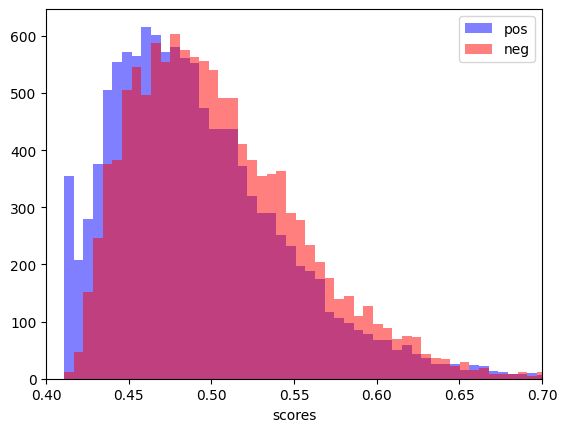

KL divergence(pos||neg): 0.3076 	 KL divergence(neg||pos):0.3224
Jensen-Shannon divergence: 0.0727
6 score


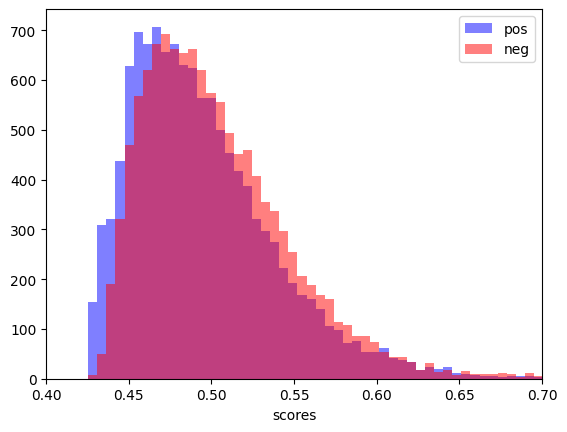

KL divergence(pos||neg): 0.3178 	 KL divergence(neg||pos):0.3353
Jensen-Shannon divergence: 0.0753
7 score


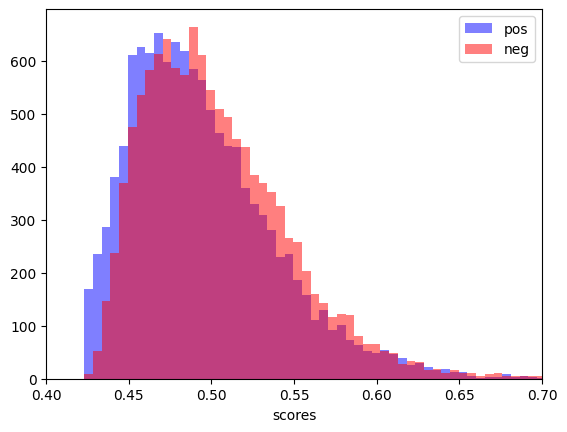

KL divergence(pos||neg): 0.3047 	 KL divergence(neg||pos):0.3158
Jensen-Shannon divergence: 0.0717
8 score


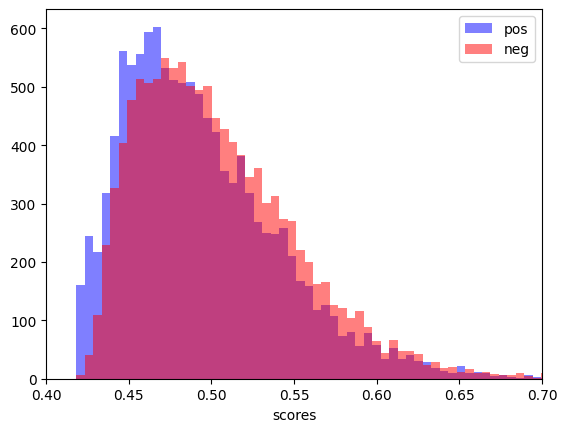

KL divergence(pos||neg): 0.3173 	 KL divergence(neg||pos):0.3309
Jensen-Shannon divergence: 0.0749
9 score


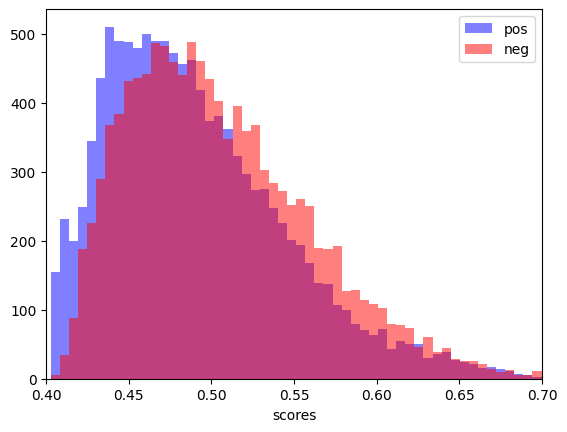

KL divergence(pos||neg): 0.3065 	 KL divergence(neg||pos):0.3196
Jensen-Shannon divergence: 0.0726
5 prob


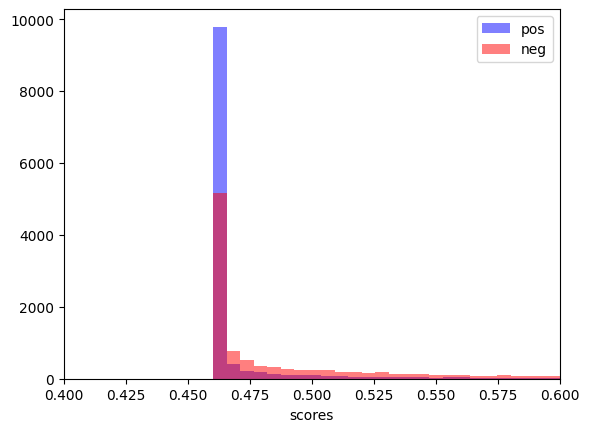

KL divergence(pos||neg): 0.0005 	 KL divergence(neg||pos):0.0005
Jensen-Shannon divergence: 0.0001
6 prob


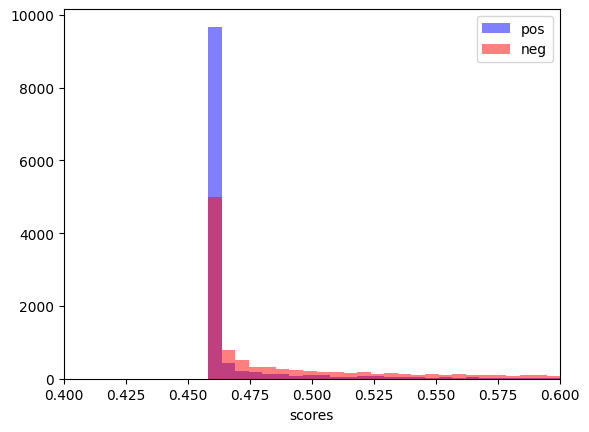

KL divergence(pos||neg): 0.0005 	 KL divergence(neg||pos):0.0005
Jensen-Shannon divergence: 0.0001
7 prob


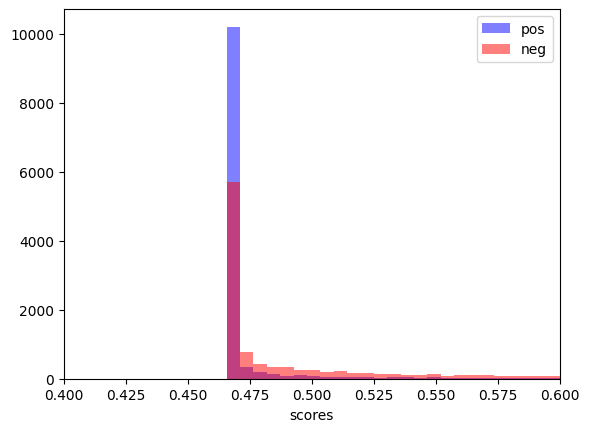

KL divergence(pos||neg): 0.0006 	 KL divergence(neg||pos):0.0005
Jensen-Shannon divergence: 0.0001
8 prob


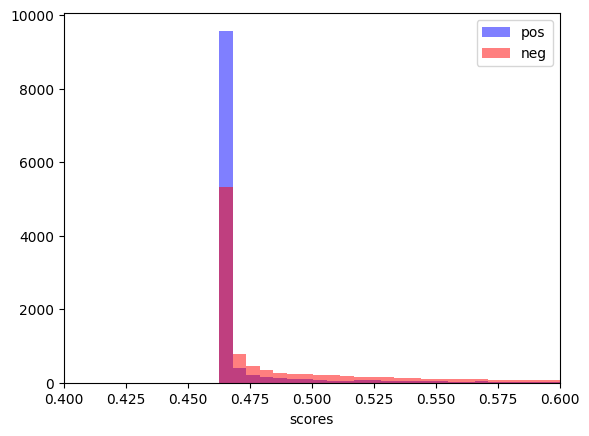

KL divergence(pos||neg): 0.0006 	 KL divergence(neg||pos):0.0006
Jensen-Shannon divergence: 0.0001
9 prob


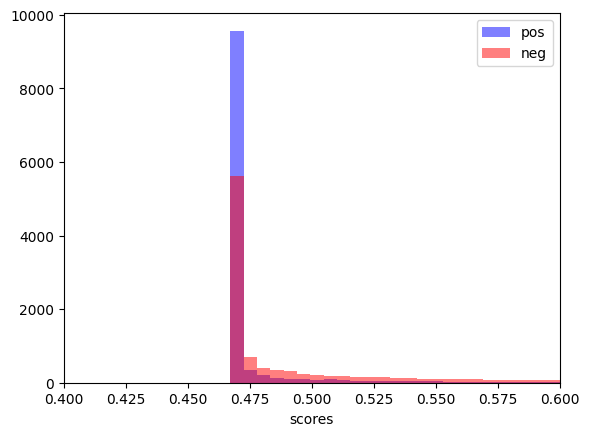

KL divergence(pos||neg): 0.0005 	 KL divergence(neg||pos):0.0005
Jensen-Shannon divergence: 0.0001


In [7]:
for cur_dir in ['srl_multi_pre_thres_un10_score_discrim']:
    print("<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
    print(cur_dir)
    for score in ['score', 'prob']:
        for ep in range(5,10):
            print('===========================================================')
            print(ep, score)

            pos = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_{score}_pos.pt').cpu().numpy()
            neg = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_{score}_neg.pt').cpu().numpy()
    #         bin_num = int(np.ceil(1 + 3.322 *np.log(pos.shape[0]+neg.shape[0])))
            bin_num = 100

            x_p = range(int(np.max(pos)))
            x_n = range(int(np.max(neg)))

            num_sample = min(pos.shape[0], neg.shape[0])

            pos = np.array(random.sample(pos.tolist(), num_sample))
            neg = np.array(random.sample(neg.tolist(), num_sample))

            x = np.concatenate((pos, neg))
            y = np.concatenate((np.zeros(pos.shape[0]), np.ones(neg.shape[0])))    # 0 -> pos // 1 -> neg

            cls = LogisticRegression()
            cls.fit(x,y)

            b, w = cls.intercept_, cls.coef_

            pos_transform = expit(pos*w+b)
            neg_transform = expit(neg*w+b)

            bins = np.linspace(min(np.min(pos_transform), np.min(neg_transform)), max(np.max(pos_transform), np.max(neg_transform)), bin_num)

            plt.hist(pos_transform, bins, alpha=0.5, label='pos', color='b')
            plt.hist(neg_transform, bins, alpha=0.5, label='neg', color='r')

            plt.xlabel('scores')
            plt.legend()
            plt.xlim(0.4, 0.7)
    #         plt.xlim(min(pos_transform.min(), neg_transform.min()) - min(pos_transform.min(), neg_transform.min())*0.1,\
    #                  max(pos_transform.max(), neg_transform.max()) + max(pos_transform.max(), neg_transform.max())*0.1)

            if score == 'prob':
                plt.xlim(0.4, 0.6)

            plt.show()
            
            print(f"KL divergence(pos||neg): {entropy(pos, neg).item():.4f} \t KL divergence(neg||pos):{entropy(neg, pos).item():.4f}")
            print(f"Jensen-Shannon divergence: {((entropy(pos, 0.5*(neg+pos))+entropy(neg, 0.5*(neg+pos)))/2).item():.4f}")

## Plot x

In [17]:
# mean: 0.9960 	 std: 0.0132 	 median: 0.9997 	 75: 0.999931812286377 	 25: 0.9984616488218307 	 iqr: 0.0014701634645462036

(0.9-0.9960)/0.0132

-7.272727272727271

<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
srl_multi_pre_thres_un10_score_discrim
0 score


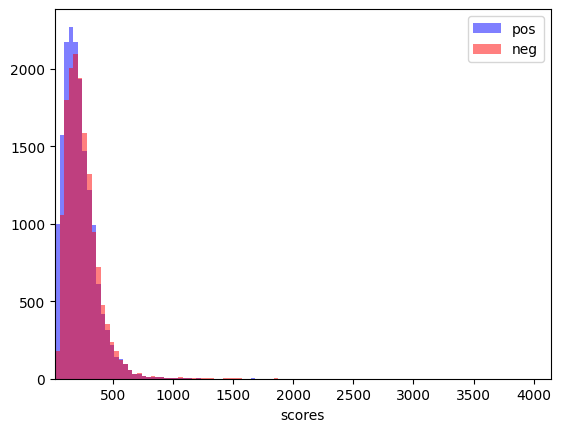

pos
16943
min:	22.0858 		 max:	1858.9808
mean:	222.8726 		 std:	136.9734
med:	198.9116 		 95.4 perencet:	478.3928

neg
15370
min:	25.1096 		 max:	3765.7412
mean:	249.0223 		 std:	149.7637
med:	221.0812 		 95.4 perencet:	507.4096

KL divergence(pos||neg): 0.3144 	 KL divergence(neg||pos):0.3313
Jensen-Shannon divergence: 0.0745
threshold: 235.0325

pos
shape: 15370 	 mean: 222.8673 	 std: 136.7318 	 median: 198.8225 	 75: 290.90885162353516 	 25: 126.10951232910156 	 iqr: 164.7993392944336
z value:	0.2648
bigger than thres:	 38.2824 %

neg
shape: 15370 	 mean: 249.0223 	 std: 149.7637 	 median: 221.0812
z value:	0.0932
bigger than thres:	 45.1334 %
1 score


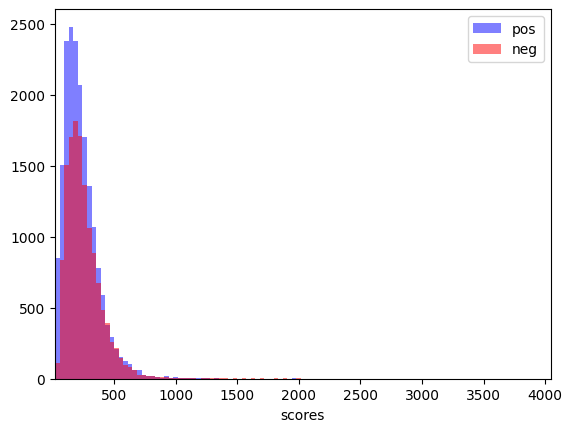

pos
18704
min:	22.8521 		 max:	2210.4976
mean:	232.2833 		 std:	143.7954
med:	203.7492 		 95.4 perencet:	505.0588

neg
13609
min:	30.7597 		 max:	3678.3225
mean:	257.9841 		 std:	162.6714
med:	225.1058 		 95.4 perencet:	531.2828

KL divergence(pos||neg): 0.3202 	 KL divergence(neg||pos):0.3350
Jensen-Shannon divergence: 0.0756
threshold: 244.3784

pos
shape: 13609 	 mean: 232.6169 	 std: 145.4770 	 median: 203.5988 	 75: 297.7181091308594 	 25: 132.648681640625 	 iqr: 165.06942749023438
z value:	0.2803
bigger than thres:	 37.4458 %

neg
shape: 13609 	 mean: 257.9841 	 std: 162.6714 	 median: 225.1058
z value:	0.1185
bigger than thres:	 43.5594 %
2 score


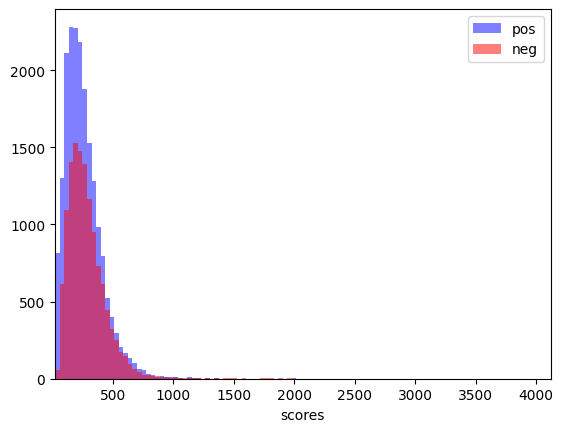

pos
19544
min:	22.2984 		 max:	2209.8149
mean:	255.4509 		 std:	155.1832
med:	227.3781 		 95.4 perencet:	548.7515

neg
12769
min:	32.9506 		 max:	3747.6384
mean:	285.1252 		 std:	171.6132
med:	253.3149 		 95.4 perencet:	576.4006

KL divergence(pos||neg): 0.3141 	 KL divergence(neg||pos):0.3269
Jensen-Shannon divergence: 0.0739
threshold: 269.4090

pos
shape: 12769 	 mean: 255.7818 	 std: 156.2031 	 median: 227.2396 	 75: 330.90728759765625 	 25: 146.91928100585938 	 iqr: 183.98800659179688
z value:	0.2700
bigger than thres:	 37.8730 %

neg
shape: 12769 	 mean: 285.1251 	 std: 171.6132 	 median: 253.3149
z value:	0.0938
bigger than thres:	 45.0388 %
3 score


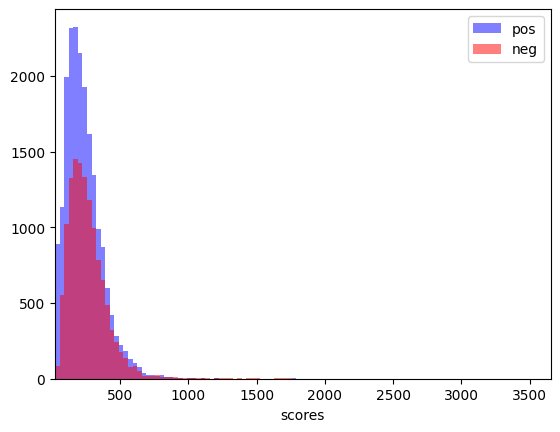

pos
19752
min:	25.3690 		 max:	1983.3075
mean:	234.2872 		 std:	135.2714
med:	210.2146 		 95.4 perencet:	490.5693

neg
12561
min:	35.6415 		 max:	3322.3784
mean:	261.9827 		 std:	153.0879
med:	235.1555 		 95.4 perencet:	516.3766

KL divergence(pos||neg): 0.2936 	 KL divergence(neg||pos):0.3092
Jensen-Shannon divergence: 0.0698
threshold: 246.8800

pos
shape: 12561 	 mean: 233.8375 	 std: 135.5426 	 median: 209.8825 	 75: 300.96527099609375 	 25: 138.78622436523438 	 iqr: 162.17904663085938
z value:	0.2730
bigger than thres:	 38.5001 %

neg
shape: 12561 	 mean: 261.9827 	 std: 153.0879 	 median: 235.1555
z value:	0.0766
bigger than thres:	 46.0314 %
4 score


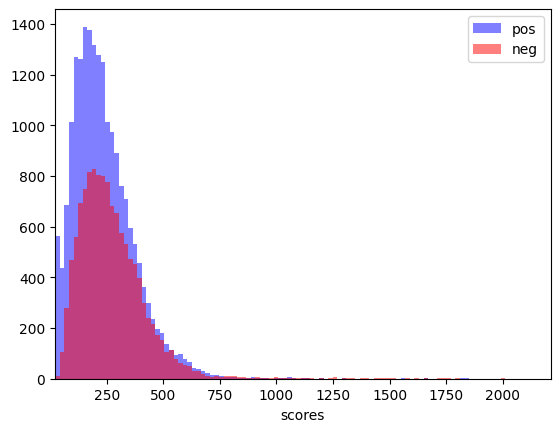

pos
19867
min:	23.4332 		 max:	1842.7550
mean:	237.1389 		 std:	135.8880
med:	213.9561 		 95.4 perencet:	495.0945

neg
12446
min:	35.1154 		 max:	2010.7644
mean:	272.3830 		 std:	150.9849
med:	247.0309 		 95.4 perencet:	529.7885

KL divergence(pos||neg): 0.2835 	 KL divergence(neg||pos):0.2971
Jensen-Shannon divergence: 0.0677
threshold: 253.5778

pos
shape: 12446 	 mean: 237.2980 	 std: 135.3875 	 median: 215.0980 	 75: 308.658935546875 	 25: 140.5033721923828 	 iqr: 168.1555633544922
z value:	0.2842
bigger than thres:	 38.1568 %

neg
shape: 12446 	 mean: 272.3830 	 std: 150.9849 	 median: 247.0309
z value:	0.0434
bigger than thres:	 47.9029 %
5 score


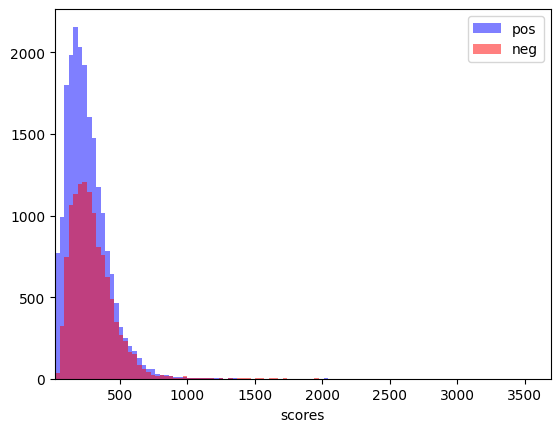

pos
20251
min:	22.0974 		 max:	3359.0710
mean:	259.2923 		 std:	156.8594
med:	230.7539 		 95.4 perencet:	552.9673

neg
12062
min:	32.3343 		 max:	1976.0092
mean:	297.0642 		 std:	167.3978
med:	267.3883 		 95.4 perencet:	588.1859

KL divergence(pos||neg): 0.3027 	 KL divergence(neg||pos):0.3211
Jensen-Shannon divergence: 0.0722
threshold: 275.8216

pos
shape: 12062 	 mean: 257.6465 	 std: 158.0220 	 median: 228.9108 	 75: 333.78663635253906 	 25: 147.8130874633789 	 iqr: 185.97354888916016
z value:	0.2969
bigger than thres:	 37.6554 %

neg
shape: 12062 	 mean: 297.0642 	 std: 167.3978 	 median: 267.3883
z value:	0.0504
bigger than thres:	 47.6289 %
6 score


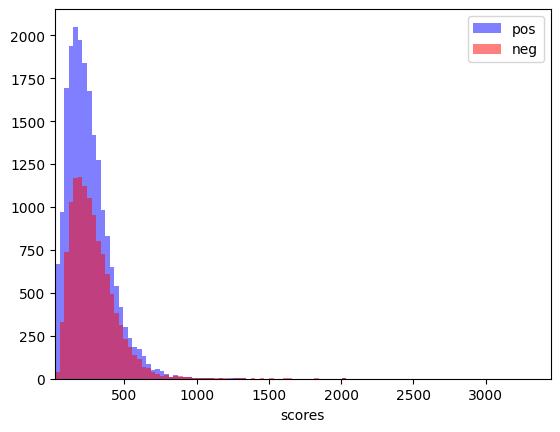

pos
20334
min:	19.8846 		 max:	2133.2456
mean:	252.1648 		 std:	152.6856
med:	223.4993 		 95.4 perencet:	544.7993

neg
11979
min:	32.6333 		 max:	3137.3965
mean:	283.2972 		 std:	168.3721
med:	251.3081 		 95.4 perencet:	575.7822

KL divergence(pos||neg): 0.3242 	 KL divergence(neg||pos):0.3394
Jensen-Shannon divergence: 0.0764
threshold: 265.8565

pos
shape: 11979 	 mean: 250.6292 	 std: 151.6169 	 median: 222.3606 	 75: 326.7674102783203 	 25: 142.1540298461914 	 iqr: 184.6133804321289
z value:	0.2869
bigger than thres:	 38.1751 %

neg
shape: 11979 	 mean: 283.2972 	 std: 168.3721 	 median: 251.3081
z value:	0.0864
bigger than thres:	 45.9972 %
7 score


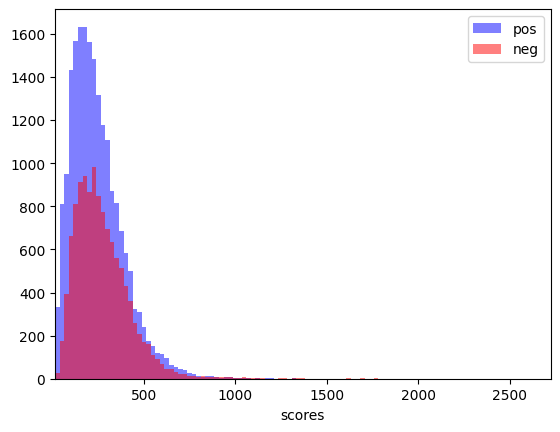

pos
20356
min:	17.5757 		 max:	2476.9124
mean:	247.6890 		 std:	148.7785
med:	220.6535 		 95.4 perencet:	525.3936

neg
11957
min:	25.3392 		 max:	1779.1843
mean:	275.0522 		 std:	155.1309
med:	246.9780 		 95.4 perencet:	545.2002

KL divergence(pos||neg): 0.3054 	 KL divergence(neg||pos):0.3131
Jensen-Shannon divergence: 0.0717
threshold: 260.9093

pos
shape: 11957 	 mean: 248.2316 	 std: 149.1240 	 median: 220.8680 	 75: 322.0840148925781 	 25: 142.46812438964844 	 iqr: 179.6158905029297
z value:	0.2685
bigger than thres:	 39.0064 %

neg
shape: 11957 	 mean: 275.0521 	 std: 155.1309 	 median: 246.9780
z value:	0.0898
bigger than thres:	 46.0651 %
8 score


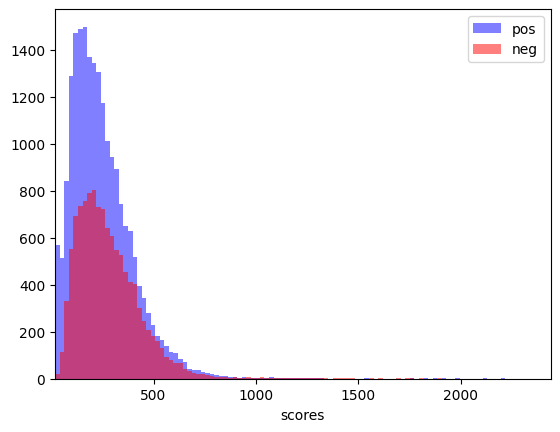

pos
20662
min:	20.6226 		 max:	2217.2039
mean:	248.1559 		 std:	152.9426
med:	219.6056 		 95.4 perencet:	536.8019

neg
11651
min:	24.8330 		 max:	1885.3994
mean:	281.3031 		 std:	161.0565
med:	251.8840 		 95.4 perencet:	563.8124

KL divergence(pos||neg): 0.3228 	 KL divergence(neg||pos):0.3335
Jensen-Shannon divergence: 0.0758
threshold: 264.2400

pos
shape: 11651 	 mean: 249.1524 	 std: 155.2340 	 median: 219.4790 	 75: 325.1614227294922 	 25: 139.24351501464844 	 iqr: 185.91790771484375
z value:	0.2883
bigger than thres:	 37.7822 %

neg
shape: 11651 	 mean: 281.3031 	 std: 161.0565 	 median: 251.8840
z value:	0.0767
bigger than thres:	 46.5196 %
9 score


FileNotFoundError: [Errno 2] No such file or directory: 'srl_multi_pre_thres_un10_score_discrim/scores/epoch_9_valid_score_pos.pt'

In [18]:
for cur_dir in dirs:
    print("<<<<<<<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
    print(cur_dir)
    for score in [ 'score']:
        for ep in range(10):
            print('===========================================================')
            print(ep, score)

            pos = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_{score}_pos.pt').cpu().numpy()
            neg = torch.load(f'{cur_dir}/scores/epoch_{ep}_valid_{score}_neg.pt').cpu().numpy()
 #         bin_num = int(np.ceil(1 + 3.322 *np.log(pos.shape[0]+neg.shape[0])))
            bin_num = 100
            bins = np.linspace(min(np.min(pos), np.min(neg)), max(np.max(pos), np.max(neg)), bin_num)

            x_p = range(int(np.max(pos)))
            x_n = range(int(np.max(neg)))

            plt.hist(pos, bins, alpha=0.5, label='pos', color='b')
            plt.hist(neg, bins, alpha=0.5, label='neg', color='r')

            plt.xlabel('scores')
            plt.legend()
            plt.xlim(min(pos.min(), neg.min()) - min(pos.min(), neg.min())*0.1, max(pos.max(), neg.max()) + max(pos.max(), neg.max())*0.1)
            if score == 'prob':
                plt.xlim(0.8, 1.1)
                plt.ylim(0, 3000)
            plt.show()

            print('pos')
            print(pos.shape[0])
            print(f"min:\t{pos.min().tolist():.4f} \t\t max:\t{pos.max().tolist():.4f}")
            print(f"mean:\t{pos.mean().tolist():.4f} \t\t std:\t{pos.std().tolist():.4f}")
            print(f"med:\t{np.quantile(pos, q=0.5).tolist():.4f} \t\t 95.4 perencet:\t{np.quantile(pos, q=0.954).tolist():.4f}")
    #         print(f"top 10: {(np.sort(pos, 0)[:-10:-1]).tolist()}")
            print()
            print('neg')
            print(neg.shape[0])
            print(f"min:\t{neg.min().tolist():.4f} \t\t max:\t{neg.max().tolist():.4f}")
            print(f"mean:\t{neg.mean().tolist():.4f} \t\t std:\t{neg.std().tolist():.4f}")
            print(f"med:\t{np.quantile(neg, q=0.5).tolist():.4f} \t\t 95.4 perencet:\t{np.quantile(neg, q=0.954).tolist():.4f}")
    #         print(f"top 10: {(np.sort(neg, 0)[:-10:-1]).tolist()}")

            num_sample = min(pos.shape[0], neg.shape[0])

            pos = np.array(random.sample(pos.tolist(), num_sample))
            neg = np.array(random.sample(neg.tolist(), num_sample))

            x = np.concatenate((pos, neg))
            y = np.concatenate((np.ones(pos.shape[0]), np.zeros(neg.shape[0])))    # 0 -> pos // 1 -> neg

            cls = LogisticRegression()
            cls.fit(x,y)

            b, w = cls.intercept_, cls.coef_
            decision_boundary = -b/w
            print()
            print(f"KL divergence(pos||neg): {entropy(pos, neg).item():.4f} \t KL divergence(neg||pos):{entropy(neg, pos).item():.4f}")
            print(f"Jensen-Shannon divergence: {((entropy(pos, 0.5*(neg+pos))+entropy(neg, 0.5*(neg+pos)))/2).item():.4f}")
            print(f"threshold: {decision_boundary.item():.4f}")
            print()
            print('pos')
            print(f"shape: {pos.shape[0]} \t mean: {pos.mean():.4f} \t std: {pos.std():.4f} \t median: {np.quantile(pos, q=0.5):.4f} \t 75: {np.quantile(pos, q=0.75)} \t 25: {np.quantile(pos, q=0.25)} \t iqr: {np.quantile(pos, q=0.75) - np.quantile(pos, q=0.25)}")
            print(f"z value:\t{((decision_boundary-np.median(pos, 0))/np.std(pos)).item():.4f}")
            print(f"bigger than thres:\t{(np.count_nonzero(pos>=decision_boundary) / pos.size)*100: .4f} %")

            print()
            print('neg')
            print(f"shape: {neg.shape[0]} \t mean: {neg.mean():.4f} \t std: {neg.std():.4f} \t median: {np.quantile(neg, q=0.5):.4f}")
            print(f"z value:\t{((decision_boundary-np.median(neg, 0))/np.std(neg)).item():.4f}")
            print(f"bigger than thres:\t{(np.count_nonzero(neg>=decision_boundary) / neg.size)*100 : .4f} %")
    break

## Pos vs Neg



 energy


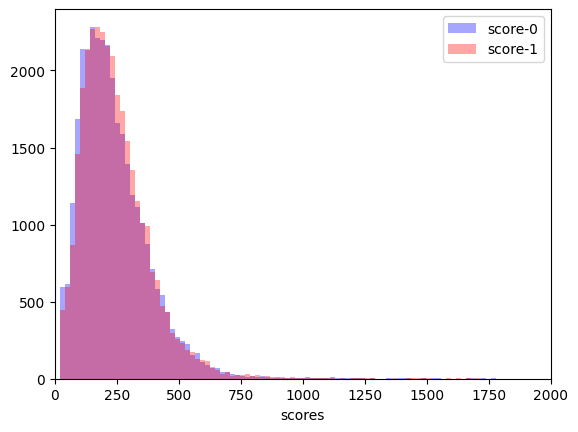

        mins         maxs       means        stds         q50         q95
0  20.729620  2992.858398  240.100708  145.016510  212.588333  505.518908
1  25.368998  3322.378418  245.053223  143.100418  220.467148  500.618763


 prob


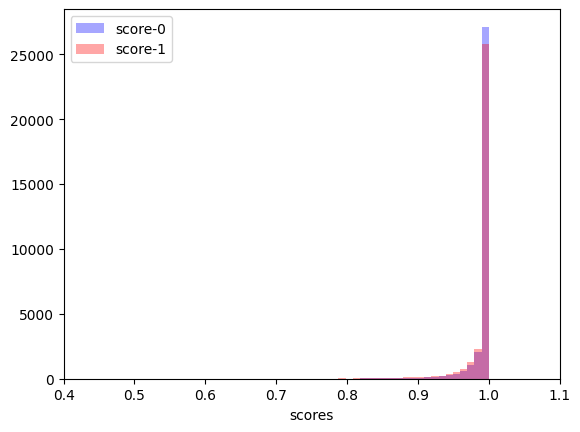

       mins      maxs     means      stds       q50       q95
0  0.645269  0.999999  0.992938  0.020907  0.999792  0.999998
1  0.625252  1.000000  0.990196  0.026389  0.999755  0.999999


_pos energy


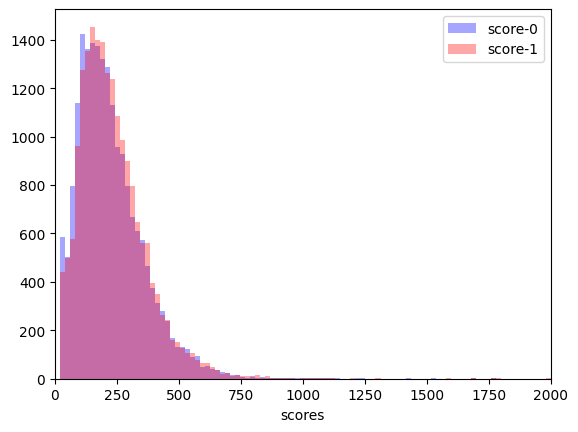

        mins         maxs       means        stds         q50         q95
0  20.729620  1765.252808  226.103775  136.297546  200.382912  486.529633
1  25.368998  1983.307495  234.287216  135.271378  210.214592  490.569309


_pos prob


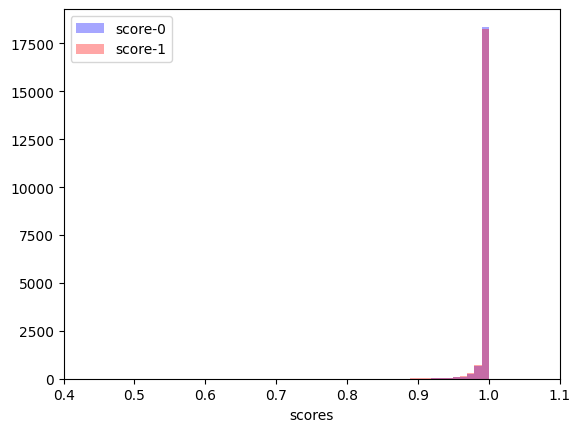

       mins      maxs     means      stds       q50       q95
0  0.714415  0.999999  0.997662  0.009639  0.999928  0.999999
1  0.687660  1.000000  0.996825  0.012974  0.999954  0.999999


_neg energy


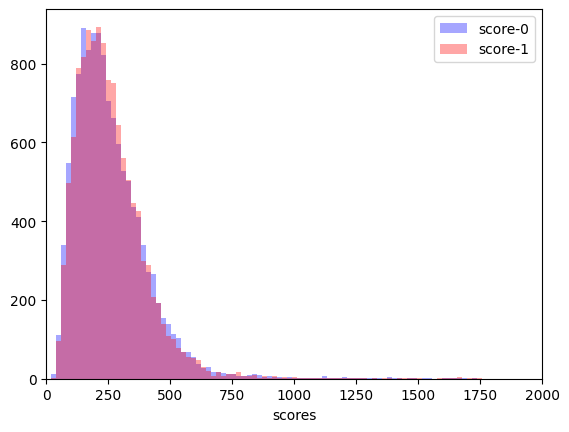

        mins         maxs       means        stds         q50         q95
0  32.159882  2992.858398  261.680145  155.059875  231.249451  526.986080
1  35.641525  3322.378418  261.982666  153.087921  235.155518  516.376565


_neg prob


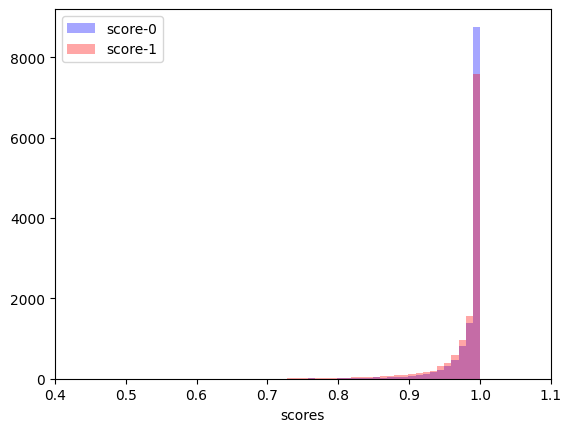

       mins      maxs     means      stds       q50       q95
0  0.645269  0.999999  0.985656  0.029671  0.997711  0.999983
1  0.625252  0.999999  0.979772  0.036729  0.994801  0.999979


In [21]:
ep = 0
score = 'energy'
colors = ['blue', 'red', 'mediumslateblue', 'mediumpurple', 'blueviolet', 'darkorchid', 'darkviolet', \
          'mediumorchid', 'violet', 'plum','magenta']
mins, maxs, means, stds, q50, q95 = [], [], [], [], [], []
for p in ['', '_pos', '_neg']:
    for score_name in ['energy', 'prob']:
        print('\n\n===========================================')
        print(p, score_name)
        score_list = []
        mins, maxs, means, stds, q50, q95 = [], [], [], [], [], []
        for dire in ['./', '../../srl_multi_pre_thres_un10/scores/']:      
            score = torch.load(f'{dire}epoch_3_valid_{score_name}{p}.pt').cpu().numpy()
            score_list.append(score)

            mins.append(round(np.min(score), 6))
            maxs.append(round(np.max(score), 6))
            means.append(round(np.mean(score), 6))
            stds.append(round(np.std(score), 6))
            q50.append(round(np.quantile(score, q=0.5), 6))
            q95.append(round(np.quantile(score, q=0.954), 6))

#         bin_num = int(np.ceil(1 + 3.322 *np.log(score.shape[0])))
        bin_num = 100
        bins = np.linspace(0, 2000, bin_num)
        if score_name == 'prob':
            bins = np.linspace(0, 1.0, bin_num)

        x_p = range(int(2000))
        for i, score in enumerate(score_list):    
            plt.hist(score, bins, alpha=0.35, label=f'score-{i}', color=colors[i])
            plt.xlabel('scores')
            plt.legend()

        plt.xlim(0, 2000)
        if score_name == 'prob':
            plt.xlim(0.4, 1.1)
        plt.show()

        import pandas as pd

        df = pd.DataFrame(list(zip(mins, maxs, means, stds, q50, q95)),
                         columns=[ "mins", "maxs", "means", "stds", "q50", "q95"])
        print(df)


In [16]:
ep = 0
score = 'energy'
colors = ['blue', 'slateblue', 'mediumslateblue', 'mediumpurple', 'blueviolet', 'darkorchid', 'darkviolet', \
          'mediumorchid', 'violet', 'plum','magenta']
mins, maxs, means, stds, q50, q95 = [], [], [], [], [], []
for p in ['', '_pos', '_neg']:
    for score_name in ['score', 'prob']:
        print('\n\n===========================================')
        print(p, score_name)
        score_list = []
        mins, maxs, means, stds, q50, q95 = [], [], [], [], [], []
        for ep in range(8):      
            score = torch.load(f'epoch_{ep}_valid_{score_name}{p}.pt').cpu().numpy()
            score_list.append(score)

            mins.append(round(np.min(score), 6))
            maxs.append(round(np.max(score), 6))
            means.append(round(np.mean(score), 6))
            stds.append(round(np.std(score), 6))
            q50.append(round(np.quantile(score, q=0.5), 6))
            q95.append(round(np.quantile(score, q=0.954), 6))

#         bin_num = int(np.ceil(1 + 3.322 *np.log(score.shape[0])))
        bin_num = 100
        bins = np.linspace(0, 2000, bin_num)
        if score_name == 'prob':
            bins = np.linspace(0, 1.0, bin_num)

        x_p = range(int(2000))
        for i, score in enumerate(score_list):    
            plt.hist(score, bins, alpha=0.35, label=f'score-{i}', color=colors[i])
            plt.xlabel('scores')
            plt.legend()

        plt.xlim(0, 2000)
        if score_name == 'prob':
            plt.xlim(0.4, 1.1)
        plt.show()

        import pandas as pd

        df = pd.DataFrame(list(zip(mins, maxs, means, stds, q50, q95)),
                         columns=[ "mins", "maxs", "means", "stds", "q50", "q95"])
        print(df)




 score


FileNotFoundError: [Errno 2] No such file or directory: 'epoch_0_valid_score.pt'